# Homework 09
https://github.com/tawest2020/taw-bios512

## Question 1
#### In the table below, fill in the definition column with a short (no more than two sentence) definition for each vocab word. If it can be summarized by a formula, give the formula.

| Vocab Word | Definition |
|:--------|:--------|
| **One-hot coding** | Converts each category into a separate binary (0/1) column |
| **Feature selection*** | Automatically restricts our regressions to just the most important variables |
| **Classifier** | A model that assigns inputs to categories (classes) instead of predicting numeric values |
| **Precision** | Proportion of true positives over total predicted positives |
| **Recall** | Proportion of true positives over total actual positives |
| **F1 Score** | The harmonic mean of the precision and the recall, requires both precision and recall to be high to have a high mean.  |
| **Parsimonious model** | A model made as simple as possible while still explaining the data |
| **Ridge regression** | Form of regression using squared penalty |
| **LASSO regression** | Form of regression using absolute value penalty |
| **Cross validation** | Compares the accuracy of two models with the distribution of the two models' accuracies and is how the penalty parameter si decided on |
| **Tree based methods** | Pose a series of questions that chops our data set up into smaller pieces for which the problem might be easier to solve. |

*Just give the general idea.

## Question 2
#### a) What shape does a perfect classifier look like on an ROC curve? What about a bad classifier?
A perfect classifier will have a rectangle shape on an ROC Curve while a bad classifier will fit a y=x line.
#### b) Think about the formula for an F1 score. What does it mean when the F1 score is close to 1? Close to 0?
When an F1 score approaches 1, this means that you are achieving a perfect capture of true positives from your predicited trues, and avoided capturing any false negatives. When an F1 score approaches 0, this means the opposite, you have completely missed all true positives AND/OR have caputred all of the false positives.

## Question 3
#### Compare the following aspects of linear vs. logistic regression.
|  | Linear | Logistic |
|:--------|:--------|:--------|
| **Chart Shape** | Straight line Fit | S-curve fit |
| **Dependent Variable Type** | Continuous | Binary/Categorical |
| **Purpose** (regression or classification) | Regression | Both |
| **Range of output variable** ($y_i$ or $p_i$) | $y_i$ | Both |
| **Method*** | Both | OLS |
| **Example of use** | Measuring BP in patients by Age | Predicting Diabetes based on genetics and lifestyle choices |  
  
*Meaning ordinary least squares or maximum likelihood estimation

## Question 4
#### Why is it important to train then test our model? How do we do that? (2-3 sentences. Not looking for code, just general explanation).
Without training and testing models you lack information on whether or not the model generalizes to new data. To test and train data you must split data into testing/training groups and fit models to training data and perform predictions on testing data instead of doing both on the entire data. You then have two plots, predicted versus actual that will show varying different results.

## Question 5
This question runs through a linear regression example. We want to predict median house value based on the other variables.
#### a) First, load the `housing.csv` data set. Look at the data in some useful way. Why is linear regression appropriate here?

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
hdf <- read.csv('housing.csv')

In [4]:
head(hdf,10)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,-122.23,37.88,41,880,322,126,8.3252,452600
2,-122.22,37.86,21,7099,2401,1138,8.3014,358500
3,-122.24,37.85,52,1467,496,177,7.2574,352100
4,-122.25,37.85,52,1274,558,219,5.6431,341300
5,-122.25,37.85,52,1627,565,259,3.8462,342200
6,-122.25,37.85,52,919,413,193,4.0368,269700
7,-122.25,37.84,52,2535,1094,514,3.6591,299200
8,-122.25,37.84,52,3104,1157,647,3.1200,241400
9,-122.26,37.84,42,2555,1206,595,2.0804,226700


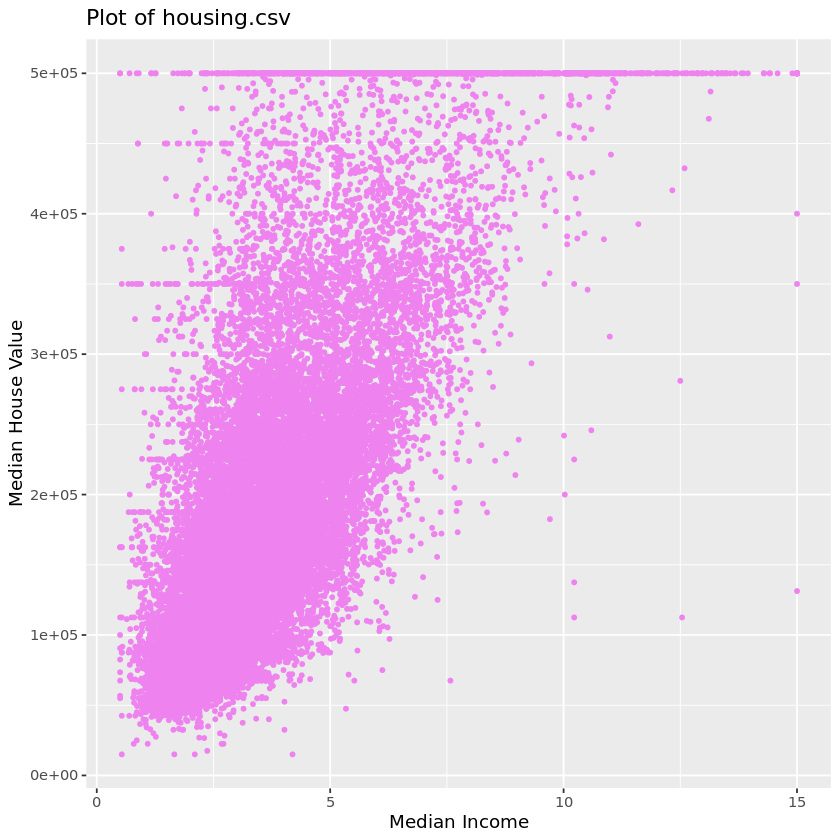

In [5]:
ggplot(hdf, aes(x = median_income, y = median_house_value)) +
  geom_point(color = "violet", size = 1) +
  labs(
    title = "Plot of housing.csv",
    x = "Median Income",
    y = "Median House Value"
  )

#### b) Scale data and split it 75/25 training/testing. Set seed = 123.

In [6]:
# Clean data.
names(hdf) <- names(hdf) %>%
  str_replace_all("-","_") %>%
  str_replace_all("[^_A-Za-z0-9]*","") %>%
  str_to_lower()

# Scale data.
scale <- function(a){
  (a - min(a))/(max(a)-min(a))
}

hdf_num <- hdf %>% select(where(is.numeric)) %>%
  mutate(across(where(is.numeric), scale))

head(hdf_num,10)

# Split data - 75% training and 25% testing.
train <- runif(nrow(hdf_num)) < 0.75
test <- !train

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.2111554,0.5674814,0.7843137,0.02233074,0.008940834,0.02055583,0.5396684,0.9022664
2,0.2121514,0.5653560,0.3921569,0.18050257,0.067210404,0.18697583,0.5380271,0.7082466
3,0.2101594,0.5642933,1.0000000,0.03726029,0.013817652,0.02894261,0.4660281,0.6950507
4,0.2091633,0.5642933,1.0000000,0.03235159,0.015555369,0.03584937,0.3546986,0.6727828
5,0.2091633,0.5642933,1.0000000,0.04132967,0.015751563,0.04242723,0.2307761,0.6746385
6,0.2091633,0.5642933,1.0000000,0.02332265,0.011491353,0.03157375,0.2439208,0.5251545
7,0.2091633,0.5632306,1.0000000,0.06442342,0.030578211,0.08436112,0.2178729,0.5859790
8,0.2091633,0.5632306,1.0000000,0.07889516,0.032343956,0.10623253,0.1806941,0.4668043
9,0.2081673,0.5632306,0.8039216,0.06493209,0.033717313,0.09768130,0.1089985,0.4364951


#### c) Fit the model.

In [7]:
# Fit model on the training data only.
f = median_house_value ~ longitude + latitude + housing_median_age + total_rooms + population + households + median_income

m <- lm(f, data=hdf_num)
summary(m)


Call:
lm(formula = f, data = hdf_num)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.11441 -0.09176 -0.02426  0.06341  1.79316 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)         0.731971   0.013470  54.341   <2e-16 ***
longitude          -0.870965   0.014825 -58.748   <2e-16 ***
latitude           -0.820504   0.013143 -62.429   <2e-16 ***
housing_median_age  0.118325   0.004564  25.924   <2e-16 ***
total_rooms        -0.143643   0.055879  -2.571   0.0102 *  
population         -3.178125   0.077069 -41.238   <2e-16 ***
households          1.873188   0.054454  34.399   <2e-16 ***
median_income       1.146522   0.009463 121.155   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1443 on 20632 degrees of freedom
Multiple R-squared:  0.6324,	Adjusted R-squared:  0.6322 
F-statistic:  5070 on 7 and 20632 DF,  p-value: < 2.2e-16


#### d) Make predictions on test data and show them in an actual vs. predicted plot.

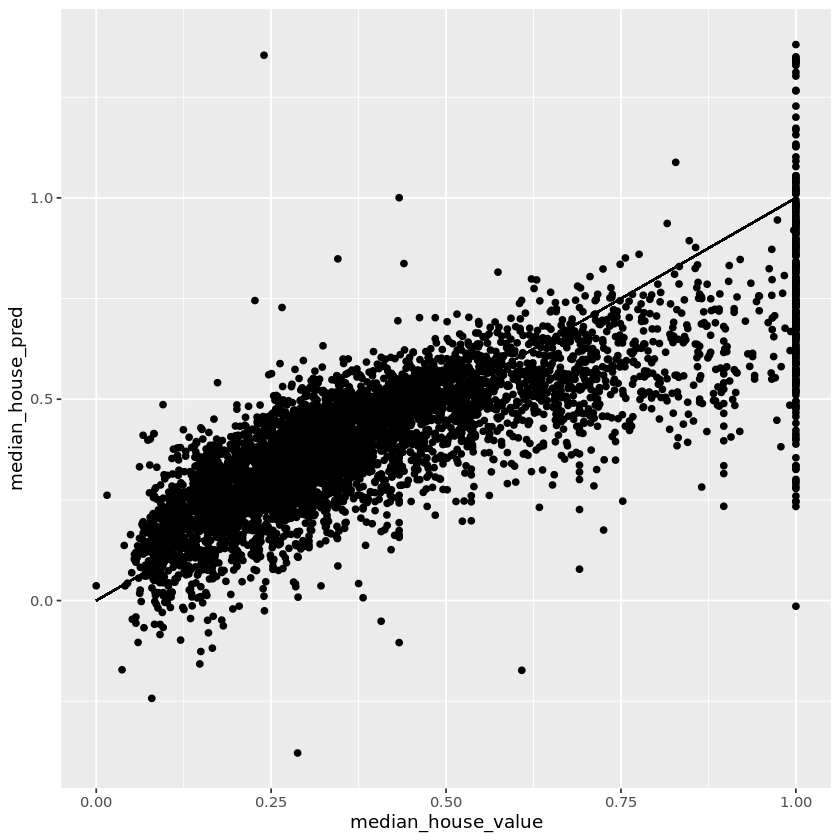

In [8]:
# Prediction on test data.
hdfx <- hdf_num %>% filter(test)

hdfx <- hdfx %>%
  mutate(median_house_pred = predict(m, hdfx %>% as.data.frame()))

# Predicted vs actual plot.
ggplot(hdfx, aes(median_house_value, median_house_pred)) + geom_point() + geom_segment(aes(x=0,y=0,xend=1,yend=1))

#### e) Make a residuals plot.


Call:
lm(formula = f, data = hdf_num)

Coefficients:
       (Intercept)           longitude            latitude  housing_median_age  
            0.7320             -0.8710             -0.8205              0.1183  
       total_rooms          population          households       median_income  
           -0.1436             -3.1781              1.8732              1.1465  


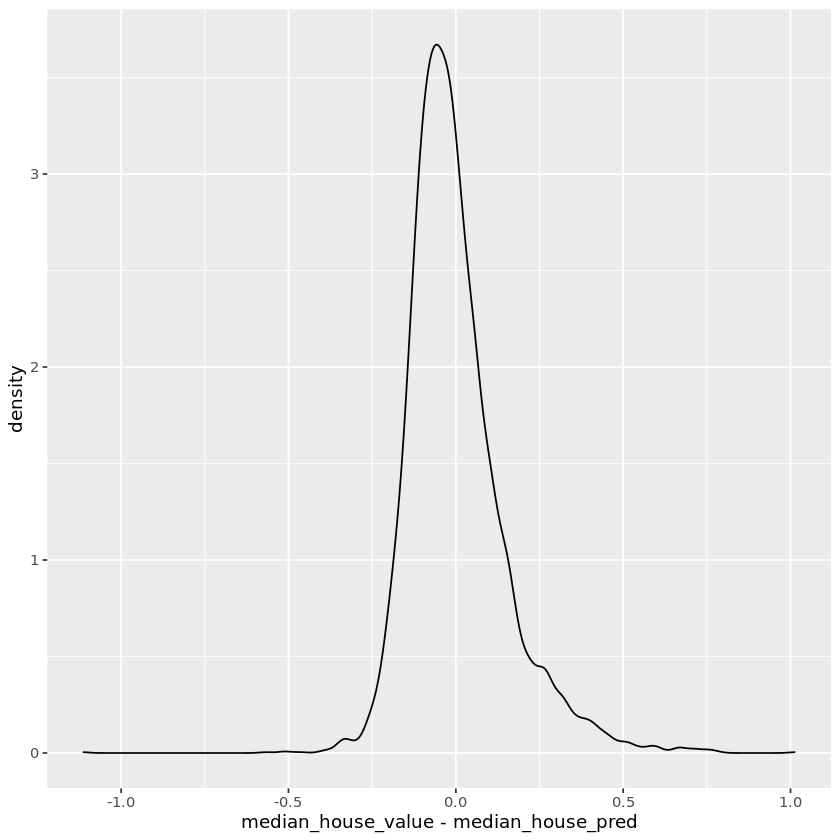

In [9]:
# Residual density plot.
ggplot(hdfx, aes(median_house_value - median_house_pred)) + geom_density()

m

## Question 6
This question runs through a logistic regression example. We want to predict diabetes diagnosis based on the other variables.
#### a) First, load the `diabetes.csv` data set. Look at the data in some useful way. Why is logistic regression appropriate here?

In [10]:
ddf <- read.csv('diabetes.csv')

In [11]:
head(ddf,10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0
7,3,78,50,32,88,31.0,0.248,26,1
8,10,115,0,0,0,35.3,0.134,29,0
9,2,197,70,45,543,30.5,0.158,53,1


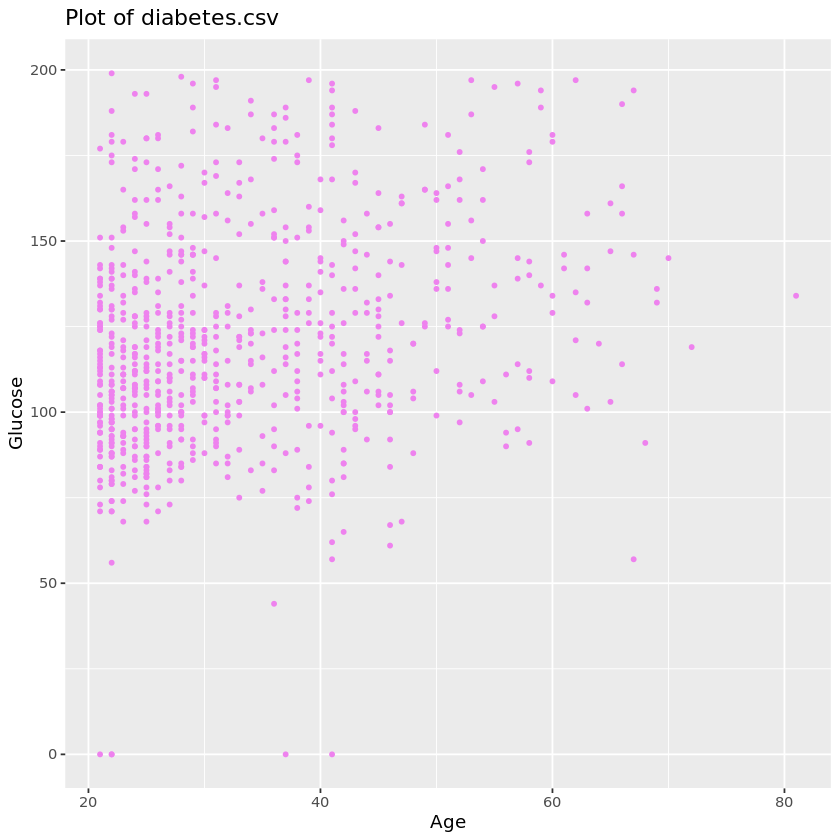

In [12]:
ggplot(ddf, aes(x = Age, y = Glucose)) +
  geom_point(color = "violet", size = 1) +
  labs(
    title = "Plot of diabetes.csv",
    x = "Age",
    y = "Glucose"
  )

#### b) Scale data and split it 75/25 training/testing. Set seed = 123.

In [13]:
scale <- function(x){
  (x - min(x)) / (max(x) - min(x))
}

ddf_num <- ddf %>% select(where(is.numeric)) %>%
  mutate(across(where(is.numeric), scale))

head(ddf,10)

set.seed(123)
n <- nrow(ddf)
train_idx <- sample.int(n, size = floor(0.1 * n))
ddf_train <- ddf %>% slice(train_idx)
ddf_test  <- ddf %>% slice(setdiff(seq_len(n), train_idx))

ddf_train %>% write_csv('diabetes_train.csv')
ddf_test  %>% write_csv('diabetes_test.csv')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0
7,3,78,50,32,88,31.0,0.248,26,1
8,10,115,0,0,0,35.3,0.134,29,0
9,2,197,70,45,543,30.5,0.158,53,1


#### c) Fit the model.

In [14]:
f <- Outcome ~ .
m <- glm(f, data = ddf_train, family = binomial())

summary(m)


Call:
glm(formula = f, family = binomial(), data = ddf_train)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -8.660739   2.427947  -3.567 0.000361 ***
Pregnancies               0.110094   0.090316   1.219 0.222848    
Glucose                   0.025308   0.011003   2.300 0.021446 *  
BloodPressure             0.001835   0.019576   0.094 0.925307    
SkinThickness             0.014549   0.023324   0.624 0.532776    
Insulin                  -0.001509   0.002434  -0.620 0.535259    
BMI                       0.108215   0.062931   1.720 0.085507 .  
DiabetesPedigreeFunction  0.307784   0.820988   0.375 0.707739    
Age                       0.016757   0.031529   0.531 0.595091    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 98.898  on 75  degrees of freedom
Residual deviance: 76.074  on 67  degrees of freedom
AIC: 94.074

Number 

#### d) Make predictions on test data. Print a table with the number of true positives, false positives, true negatives, false negatives, and accuracy.

In [15]:
p <- predict(m, newdata = ddf_test, type = "response")
pred <- as.integer(p >= 0.5)
truth <- ddf_test$Outcome

tp <- sum(pred == 1 & truth == 1)
fp <- sum(pred == 1 & truth == 0)
tn <- sum(pred == 0 & truth == 0)
fn <- sum(pred == 0 & truth == 1)
acc <- (tp + tn) / (tp + fp + tn + fn)

ddfx <- tibble(
  measure = c("True Positive", "False Positive", "True Negative", "False Negative", "Accuracy"),
  value   = c(tp, fp, tn, fn, acc)
)

ddfx

measure,value
<chr>,<dbl>
True Positive,147.0000000
False Positive,72.0000000
True Negative,379.0000000
False Negative,94.0000000
Accuracy,0.7601156


#### e) Fit a LASSO-regularized logistic regression model. Again, set seed = 123. Which variables are the most important (which ones don't go to zero)? How does the LASSO model affect the accuracy?

DiabetesPedigreeFunction  0.1374339816  
BMI                       0.0127488854  
Pregnancies               0.0199336782  


In [19]:
install.packages("glmnet")
(library(glmnet))

set.seed(123)
# Response and predictor matrices
y <- ddf$Outcome
X <- model.matrix(Outcome ~ ., ddf)[, -1]   # remove intercept column

# Fit cross-validated LASSO
cvfit <- cv.glmnet(X, y, alpha = 1)
fit <- cvfit$glmnet.fit

best_fit <- glmnet(X,y,lambda=cvfit$lambda.min)
best_fit$beta

Installing package into ‘/srv/rlibs’
(as ‘lib’ is unspecified)



[1] "broom"     "glmnet"    "Matrix"    "lubridate" "forcats"   "stringr"  
 [7] "dplyr"     "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"  
[13] "tidyverse" "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[19] "methods"   "base"

8 x 1 sparse Matrix of class "dgCMatrix"
                                    s0
Pregnancies               0.0199336782
Glucose                   0.0057930295
BloodPressure            -0.0020190738
SkinThickness             .           
Insulin                  -0.0001251608
BMI                       0.0127488854
DiabetesPedigreeFunction  0.1374339816
Age                       0.0024245727

#### f) Make a plot of actual vs. predicted values for the LASSO model.

Unable to create predicted

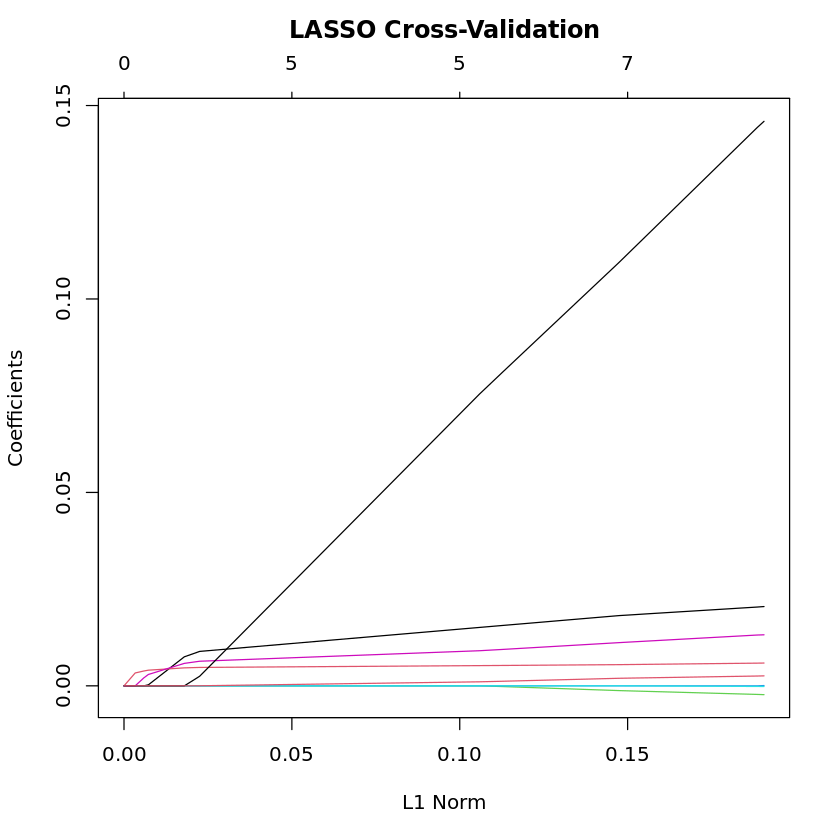

In [20]:
plot(fit)
title("LASSO Cross-Validation", line = 2.5)